# I Реализовать заданные архитектуры нейронных сетей, обучить и протестировать их на наборе данных MNIST (черно-белые рукописные цифры).
Для выполнения задания можно использовать любой фреймворк глубокого обучения на выбор (Keras, PyTorch).

0.  Загрузить необходимые библиотеки
1. Загрузить данные для обучения и тестирования
Набор данных можно загрузить из класса Datasets используемой библиотеки.
2. Предобработать данные при необходимости (нормализация, перевод целевой переменной в one-hot формат)
3. Создать модель для обучения

Модель 1
Входной слой
Скрытый полносвязный слой - 64 нейрона
Функция активации - ReLU
Выходной слой, функция активации Softmax

Модель 2
Сверточный слой, кол-во фильтров - 24, размер ядра 3x3
Функция активации - ReLU
Скрытый полносвязный слой - 128 нейронов
Функция активации - ReLU
Выходной слой, функция активации Softmax

4. Обучить модели (параметры обучения выбрать самостоятельно), вывести графики функции потерь и точности (accuracy) на обучающей и валидационной выборках
5. Протестировать модели, оценить результаты (сделать выводы)
6. (опционально) Попробовать улучшить модели, не забывая про возможное переобучение

Импорт библиотек

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras import layers

from sklearn.metrics import confusion_matrix, classification_report


In [2]:
# Чтобы результаты воспроизводились
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

Загрузка MNIST (train/test)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train: (60000, 28, 28) y_train: (60000,)
x_test : (10000, 28, 28) y_test : (10000,)


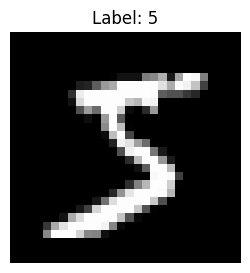

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_test :", x_test.shape,  "y_test :", y_test.shape)

# Посмотрим на один пример
plt.figure(figsize=(3, 3))
plt.imshow(x_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()


Предобработка данных (нормализация + one-hot)

In [4]:
# Нормализация: из [0..255] в [0..1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Для CNN нужно добавить канал (28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test  = np.expand_dims(x_test, axis=-1)

num_classes = 10

# Перевод меток в one-hot формат
y_train_oh = keras.utils.to_categorical(y_train, num_classes)
y_test_oh  = keras.utils.to_categorical(y_test, num_classes)

print("x_train:", x_train.shape, "y_train_oh:", y_train_oh.shape)


x_train: (60000, 28, 28, 1) y_train_oh: (60000, 10)


Вспомогательные функции: графики и оценка модели

In [5]:
def plot_history(history, title_prefix=""):
    """
    Рисует loss/accuracy на train и val по данным history
    """
    hist = history.history

    # Loss
    plt.figure(figsize=(6, 4))
    plt.plot(hist["loss"], label="train loss")
    plt.plot(hist["val_loss"], label="val loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Accuracy
    plt.figure(figsize=(6, 4))
    plt.plot(hist["accuracy"], label="train acc")
    plt.plot(hist["val_accuracy"], label="val acc")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


def evaluate_and_report(model, x_test, y_test_int, y_test_oh, title="Model"):
    """
    Оценивает модель на test, печатает accuracy/loss,
    строит confusion matrix и classification report.
    """
    print(f"\n=== {title}: test evaluation ===")
    loss, acc = model.evaluate(x_test, y_test_oh, verbose=0)
    print(f"Test loss: {loss:.4f}")
    print(f"Test acc : {acc:.4f}")

    # Предсказания: вероятности -> классы
    y_prob = model.predict(x_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    # Confusion matrix
    cm = confusion_matrix(y_test_int, y_pred)
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"{title} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    plt.show()

    # Classification report
    print("\nClassification report:")
    print(classification_report(y_test_int, y_pred, digits=4))


Создание и обучение моделей
Модель 1: MLP (Flatten -> Dense(64, ReLU) -> Dense(10, Softmax))

Требования:

Входной слой

Скрытый полносвязный слой: 64 нейрона, ReLU

Выходной слой: Softmax

In [6]:
model1 = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),   # вход (картинка 28x28x1)
    layers.Flatten(),                  # преобразуем в вектор длиной 784
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
], name="MLP_64")

model1.summary()


Model: "MLP_64"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Обучение

In [7]:
model1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Параметры обучения
history1 = model1.fit(
    x_train, y_train_oh,
    epochs=10,
    batch_size=128,
    validation_split=0.1,  # 10% train уйдет в валидацию
    verbose=1
)


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7989 - loss: 0.7486 - val_accuracy: 0.9458 - val_loss: 0.2040
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9321 - loss: 0.2381 - val_accuracy: 0.9585 - val_loss: 0.1580
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9487 - loss: 0.1812 - val_accuracy: 0.9642 - val_loss: 0.1343
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9574 - loss: 0.1478 - val_accuracy: 0.9658 - val_loss: 0.1209
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9651 - loss: 0.1245 - val_accuracy: 0.9667 - val_loss: 0.1113
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9699 - loss: 0.1070 - val_accuracy: 0.9695 - val_loss: 0.1042
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9738 - loss: 0.0934 - val_accuracy: 0.9708 - val_loss: 0.0987
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9768 - loss: 0.0829 - val_accuracy: 0.

Графики loss/accuracy

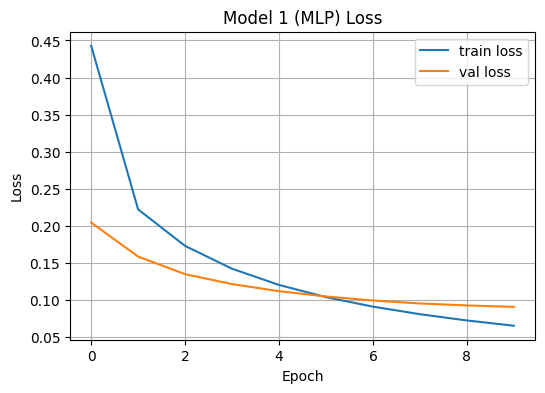

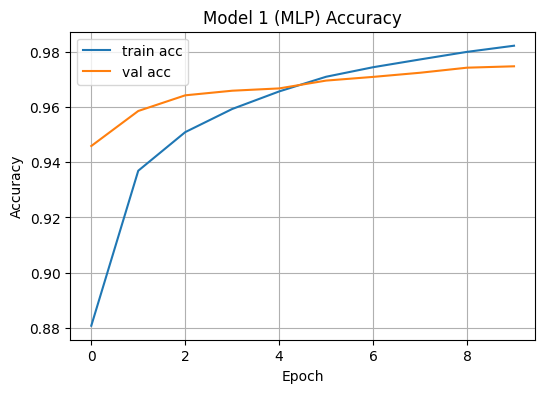

In [8]:
plot_history(history1, title_prefix="Model 1 (MLP)")


Тестирование


=== Model 1 (MLP): test evaluation ===
Test loss: 0.0985
Test acc : 0.9716


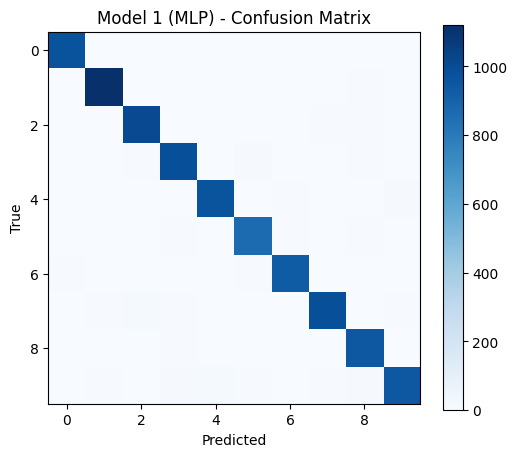


Classification report:
              precision    recall  f1-score   support

           0     0.9828    0.9888    0.9858       980
           1     0.9825    0.9868    0.9846      1135
           2     0.9664    0.9758    0.9711      1032
           3     0.9629    0.9752    0.9690      1010
           4     0.9678    0.9807    0.9742       982
           5     0.9633    0.9697    0.9665       892
           6     0.9779    0.9708    0.9743       958
           7     0.9791    0.9591    0.9690      1028
           8     0.9526    0.9702    0.9613       974
           9     0.9793    0.9376    0.9580      1009

    accuracy                         0.9716     10000
   macro avg     0.9715    0.9715    0.9714     10000
weighted avg     0.9717    0.9716    0.9716     10000



In [9]:
evaluate_and_report(model1, x_test, y_test, y_test_oh, title="Model 1 (MLP)")

Модель 2: CNN (Conv2D(24,3x3,ReLU) -> Dense(128,ReLU) -> Softmax)

Требования:

Сверточный слой: 24 фильтра, ядро 3×3, ReLU

Скрытый полносвязный слой: 128 нейронов, ReLU

Выход: Softmax

In [10]:
model2 = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # Сверточный слой по условию
    layers.Conv2D(filters=24, kernel_size=(3, 3), activation="relu"),

    # Переход к Dense: разворачиваем 3D-тензор в вектор
    layers.Flatten(),

    # Полносвязный слой по условию
    layers.Dense(128, activation="relu"),

    # Выход
    layers.Dense(10, activation="softmax")
], name="CNN_24_3x3_Dense128")

model2.summary()


Model: "CNN_24_3x3_Dense128"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 24)     │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16224)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,076,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,078,330 (7.93 MB)

 Trainable params: 2,078,330 (7.93 MB)

 Non-trainable params: 0 (0.00 B)

Обучение

In [11]:
model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model2.fit(
    x_train, y_train_oh,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 33s 76ms/step - accuracy: 0.8955 - loss: 0.3617 - val_accuracy: 0.9795 - val_loss: 0.0712
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 30s 72ms/step - accuracy: 0.9805 - loss: 0.0640 - val_accuracy: 0.9840 - val_loss: 0.0613
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 79ms/step - accuracy: 0.9888 - loss: 0.0361 - val_accuracy: 0.9845 - val_loss: 0.0614
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 77ms/step - accuracy: 0.9945 - loss: 0.0211 - val_accuracy: 0.9838 - val_loss: 0.0659
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 31s 74ms/step - accuracy: 0.9962 - loss: 0.0145 - val_accuracy: 0.9835 - val_loss: 0.0747
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 32s 76ms/step - accuracy: 0.9970 - loss: 0.0108 - val_accuracy: 0.9828 - val_loss: 0.0777
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - accuracy: 0.9975 - loss: 0.0084 - val_accuracy: 0.9847 - val_loss: 0.0740
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 74ms/step - accuracy: 0.9983 - loss: 0.0061 - 

Графики loss/accuracy

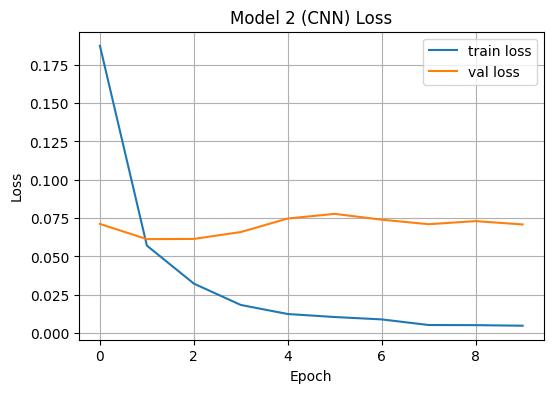

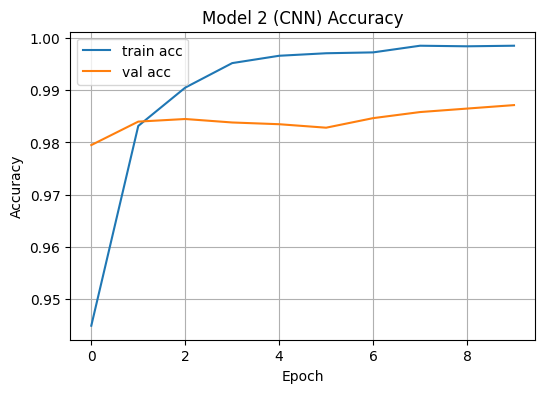

In [12]:
plot_history(history2, title_prefix="Model 2 (CNN)")

Тестирование


=== Model 2 (CNN): test evaluation ===
Test loss: 0.0601
Test acc : 0.9860


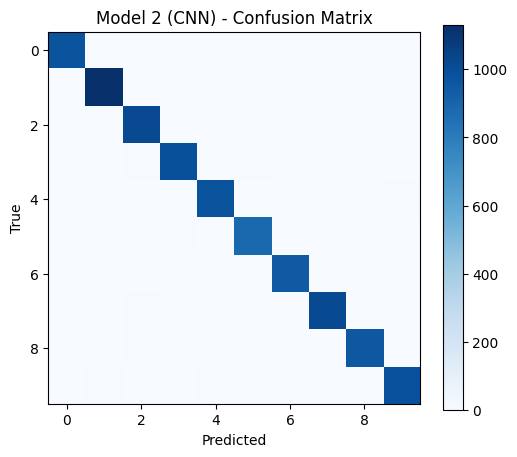


Classification report:
              precision    recall  f1-score   support

           0     0.9848    0.9929    0.9888       980
           1     0.9912    0.9947    0.9930      1135
           2     0.9779    0.9855    0.9817      1032
           3     0.9861    0.9822    0.9841      1010
           4     0.9888    0.9929    0.9909       982
           5     0.9865    0.9843    0.9854       892
           6     0.9895    0.9864    0.9880       958
           7     0.9844    0.9835    0.9839      1028
           8     0.9835    0.9805    0.9820       974
           9     0.9870    0.9762    0.9816      1009

    accuracy                         0.9860     10000
   macro avg     0.9860    0.9859    0.9859     10000
weighted avg     0.9860    0.9860    0.9860     10000



In [13]:
evaluate_and_report(model2, x_test, y_test, y_test_oh, title="Model 2 (CNN)")

Улучшение модели 2 (борьба с переобучением)

добавим MaxPooling (уменьшит размерность и шум),

добавим Dropout (регуляризация),

добавим EarlyStopping (остановка при ухудшении val_loss).

Model: "Improved_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 24)     │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4056)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       519,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 520,826 (1.99 MB)

 Trainable params: 520,826 (1.99 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - accuracy: 0.8302 - loss: 0.5604 - val_accuracy: 0.9755 - val_loss: 0.0929
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 54ms/step - accuracy: 0.9603 - loss: 0.1319 - val_accuracy: 0.9815 - val_loss: 0.0635
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.9714 - loss: 0.0921 - val_accuracy: 0.9840 - val_loss: 0.0541
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.9778 - loss: 0.0716 - val_accuracy: 0.9868 - val_loss: 0.0497
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 54ms/step - accuracy: 0.9818 - loss: 0.0612 - val_accuracy: 0.9890 - val_loss: 0.0462
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.9843 - loss: 0.0533 - val_accuracy: 0.9873 - val_loss: 0.0432
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.9845 - loss: 0.0474 - val_accuracy: 0.9890 - val_loss: 0.0428
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.9867 - loss: 0.0425 - 

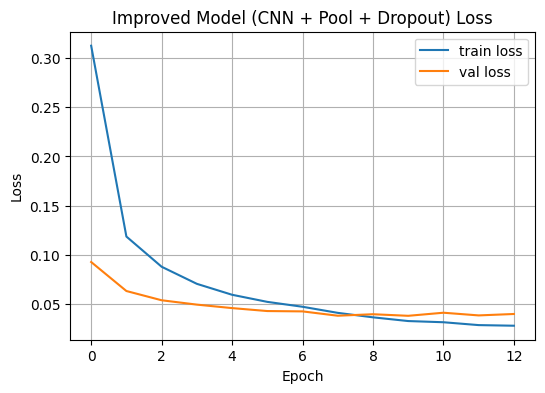

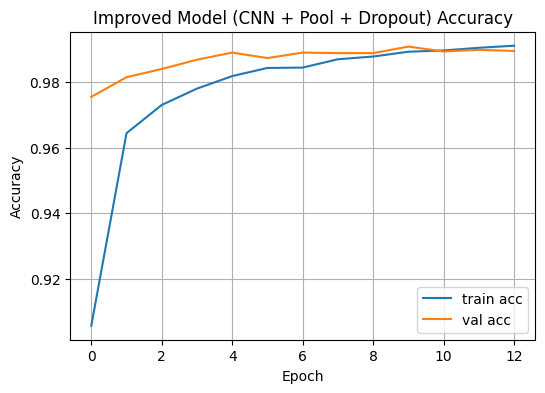


=== Improved Model (CNN): test evaluation ===
Test loss: 0.0356
Test acc : 0.9883


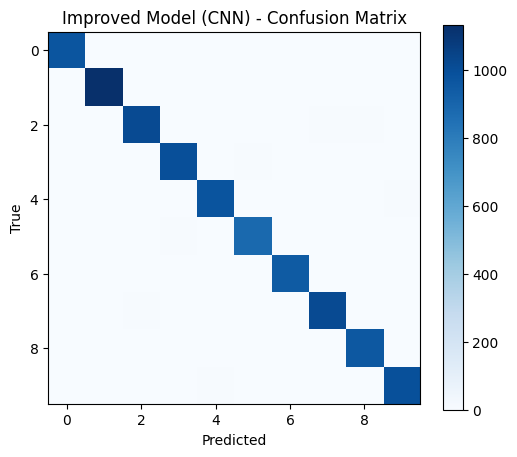


Classification report:
              precision    recall  f1-score   support

           0     0.9878    0.9908    0.9893       980
           1     0.9930    0.9974    0.9952      1135
           2     0.9893    0.9845    0.9869      1032
           3     0.9852    0.9891    0.9872      1010
           4     0.9888    0.9929    0.9909       982
           5     0.9877    0.9877    0.9877       892
           6     0.9916    0.9854    0.9885       958
           7     0.9874    0.9874    0.9874      1028
           8     0.9846    0.9846    0.9846       974
           9     0.9871    0.9822    0.9846      1009

    accuracy                         0.9883     10000
   macro avg     0.9882    0.9882    0.9882     10000
weighted avg     0.9883    0.9883    0.9883     10000



In [14]:
improved_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(24, (3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),   # уменьшили 28x28 -> 13x13 (после conv: 26x26 -> pool -> 13x13)
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
], name="Improved_CNN")

improved_model.summary()

improved_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,           # сколько эпох терпим ухудшение
    restore_best_weights=True
)

history3 = improved_model.fit(
    x_train, y_train_oh,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

plot_history(history3, title_prefix="Improved Model (CNN + Pool + Dropout)")
evaluate_and_report(improved_model, x_test, y_test, y_test_oh, title="Improved Model (CNN)")


## Выводы по тестированию

- Model 1 (MLP): точность на тесте 0.9716, loss 0.0985. Матрица ошибок почти диагональная, но ошибок заметно больше, чем у CNN. По отчету хуже всего распознается класс 9 (recall ≈ 0.9376), также слабее по сравнению с другими классами 8/7.

- Model 2 (CNN): точность на тесте 0.9860, loss 0.0601 - заметно лучше MLP. Ошибок меньше, что видно по более "чистой" диагонали confusion matrix. Улучшение ожидаемо, т.к. свертка лучше извлекает локальные признаки (штрихи/контуры) и учитывает структуру изображения.

- Improved CNN: точность 0.9883, loss 0.0356 - еще небольшое улучшение относительно базовой CNN. Прирост по accuracy уже небольшой (эффект "затухающих улучшений"), но loss стал ниже, а ошибки по классам более равномерные - регуляризация (Dropout/Pooling/EarlyStopping) помогает снизить переобучение и стабилизировать качество.

# II. Прямой проход простой RNN

Дано:
- Размерность входа: $d_x=3$
- Размерность скрытого состояния: $d_h=2$
- Размерность выхода: $d_y=2$
- Активации:
  - скрытое состояние: $tanh$
  - выход: $softmax$

Входная последовательность (one-hot):
- $x_1=[1,0,0]$ - "я"
- $x_2=[0,1,0]$ - "люблю"
- $x_3=[0,0,1]$ - "моделирование"

Начальное состояние:
$$
h_0 = [0,0]
$$


## Формулы RNN

Для каждого шага $t$:

$$
a_t = W_{xh}x_t + W_{hh}h_{t-1} + b_h
$$

$$
h_t = tanh(a_t)
$$

$$
y_t = W_{hy}h_t + b_y
$$

Здесь $y_t$ - логиты


## Задаем входы и параметры сети

По условию веса и смещения нужно задать самостоятельно из диапазона $[-1, 1]$.

Размерности:
- $x_t \in R^3$
- $h_t \in R^2$
- $y_t \in R^2$
- $W_{xh}\in R^{2\times 3}$, $W_{hh}\in R^{2\times 2}$, $W_{hy}\in R^{2\times 2}$
- $b_h\in R^2$, $b_y\in R^2$


In [15]:
# Входные векторы (one-hot) из условия
x1 = np.array([1, 0, 0])  # "я"
x2 = np.array([0, 1, 0])  # "люблю"
x3 = np.array([0, 0, 1])  # "моделирование"

# Начальное скрытое состояние
h0 = np.array([0.0, 0.0])

# Веса и смещения (все значения в диапазоне [-1, 1])
W_xh = np.array([
    [ 0.5, -0.3,  0.8],
    [-0.7,  0.2,  0.1]
])  # shape (2,3)

W_hh = np.array([
    [ 0.4, -0.6],
    [ 0.9,  0.1]
])  # shape (2,2)

b_h = np.array([ 0.1, -0.2])  # shape (2,)

W_hy = np.array([
    [ 1.0, -0.5],
    [-0.3,  0.7]
])  # shape (2,2)

b_y = np.array([ 0.05, -0.1])  # shape (2,)

all_params = np.concatenate([
    W_xh.flatten(), W_hh.flatten(), W_hy.flatten(),
    b_h.flatten(), b_y.flatten()
])
print("Параметры в [-1, 1]?:", np.all(all_params >= -1) and np.all(all_params <= 1))


Параметры в [-1, 1]?: True


## Реализуем один шаг RNN

На каждом шаге считаем:
1) $$a_t = W_{xh}x_t + W_{hh}h_{t-1} + b_h$$
2) $$h_t = tanh(a_t)$$
3) $$y_t = W_{hy}h_t + b_y$$


In [16]:
# Один шаг RNN
def rnn_step(x_t, h_prev, W_xh, W_hh, b_h, W_hy, b_y):
    """
    Выполняет прямой проход на одном временном шаге t:
    a_t = W_xh x_t + W_hh h_{t-1} + b_h
    h_t = tanh(a_t)
    y_t = W_hy h_t + b_y

    Возвращаем:
    - a_t: предактивация скрытого слоя
    - h_t: скрытое состояние
    - y_t: логиты выхода
    """
    a_t = W_xh @ x_t + W_hh @ h_prev + b_h
    h_t = np.tanh(a_t)
    y_t = W_hy @ h_t + b_y
    return a_t, h_t, y_t

def fmt(v, nd=4):
    return np.array2string(v, formatter={'float_kind':lambda x: f"{x: .{nd}f}"})

## Прямой проход для t=1,2,3

### t=1
Так как $x_1$ - one-hot, то $W_{xh}x_1$ равен 1-му столбцу $W_{xh}$.

Также $h_0=[0,0]$, значит $W_{hh}h_0=[0,0]$.

Далее:
$$
a_1 = W_{xh}x_1 + W_{hh}h_0 + b_h
$$
$$
h_1 = tanh(a_1)
$$
$$
y_1 = W_{hy}h_1 + b_y
$$


In [17]:
# t = 1
Wxh_x1 = W_xh @ x1                 # вклад входа
Whh_h0 = W_hh @ h0                 # вклад предыдущего состояния
a1, h1, y1 = rnn_step(x1, h0, W_xh, W_hh, b_h, W_hy, b_y)

print("t=1")
print("W_xh @ x1 =", fmt(Wxh_x1))
print("W_hh @ h0 =", fmt(Whh_h0))
print("a1        =", fmt(a1))
print("h1        =", fmt(h1))
print("y1 logits =", fmt(y1))


t=1
W_xh @ x1 = [ 0.5000 -0.7000]
W_hh @ h0 = [ 0.0000  0.0000]
a1        = [ 0.6000 -0.9000]
h1        = [ 0.5370 -0.7163]
y1 logits = [ 0.9452 -0.7625]


### t=2
Так как $x_2$ - one-hot, то $W_{xh}x_2$ равен 2-му столбцу $W_{xh}$.

Далее считаем вклад прошлого состояния $W_{hh}h_1$ и все суммируем:
$$
a_2 = W_{xh}x_2 + W_{hh}h_1 + b_h
$$
$$
h_2 = tanh(a_2)
$$
$$
y_2 = W_{hy}h_2 + b_y
$$


In [18]:
# t = 2
Wxh_x2 = W_xh @ x2
Whh_h1 = W_hh @ h1
a2, h2, y2 = rnn_step(x2, h1, W_xh, W_hh, b_h, W_hy, b_y)

print("t=2")
print("W_xh @ x2 =", fmt(Wxh_x2))
print("W_hh @ h1 =", fmt(Whh_h1))
print("a2        =", fmt(a2))
print("h2        =", fmt(h2))
print("y2 logits =", fmt(y2))


t=2
W_xh @ x2 = [-0.3000  0.2000]
W_hh @ h1 = [ 0.6446  0.4117]
a2        = [ 0.4446  0.4117]
h2        = [ 0.4174  0.3899]
y2 logits = [ 0.2725  0.0477]


### t=3
Так как $x_3$ - one-hot, то $W_{xh}x_3$ равен 3-му столбцу $W_{xh}$.

Далее:
$$
a_3 = W_{xh}x_3 + W_{hh}h_2 + b_h
$$
$$
h_3 = tanh(a_3)
$$
$$
y_3 = W_{hy}h_3 + b_y
$$


In [19]:
# t = 3
Wxh_x3 = W_xh @ x3
Whh_h2 = W_hh @ h2
a3, h3, y3 = rnn_step(x3, h2, W_xh, W_hh, b_h, W_hy, b_y)

print("t=3")
print("W_xh @ x3 =", fmt(Wxh_x3))
print("W_hh @ h2 =", fmt(Whh_h2))
print("a3        =", fmt(a3))
print("h3        =", fmt(h3))
print("y3 logits =", fmt(y3))


t=3
W_xh @ x3 = [ 0.8000  0.1000]
W_hh @ h2 = [-0.0670  0.4147]
a3        = [ 0.8330  0.3147]
h3        = [ 0.6821  0.3047]
y3 logits = [ 0.5797 -0.0913]


Итоговые значения $a_t$, $h_t$, $y_t$ для $t=1,2,3$.


In [20]:
# Сводная таблица
print("Итог:")
print("t=1: a1 =", fmt(a1), " h1 =", fmt(h1), " y1 =", fmt(y1))
print("t=2: a2 =", fmt(a2), " h2 =", fmt(h2), " y2 =", fmt(y2))
print("t=3: a3 =", fmt(a3), " h3 =", fmt(h3), " y3 =", fmt(y3))


Итог:
t=1: a1 = [ 0.6000 -0.9000]  h1 = [ 0.5370 -0.7163]  y1 = [ 0.9452 -0.7625]
t=2: a2 = [ 0.4446  0.4117]  h2 = [ 0.4174  0.3899]  y2 = [ 0.2725  0.0477]
t=3: a3 = [ 0.8330  0.3147]  h3 = [ 0.6821  0.3047]  y3 = [ 0.5797 -0.0913]


## Вероятности после softmax

Применяем:
$$
softmax(z)_i = \frac{e^{z_i}}{\sum_j e^{z_j}}
$$


In [21]:
# softmax
def softmax(z):
    z = z - np.max(z)        # численная стабилизация
    e = np.exp(z)
    return e / np.sum(e)

print("softmax(y1) =", fmt(softmax(y1)))
print("softmax(y2) =", fmt(softmax(y2)))
print("softmax(y3) =", fmt(softmax(y3)))


softmax(y1) = [ 0.8465  0.1535]
softmax(y2) = [ 0.5560  0.4440]
softmax(y3) = [ 0.6617  0.3383]


## Выводы

- Выполнен прямой проход RNN для трёх входных слов $x_1, x_2, x_3$ с начальным состоянием $h_0=[0,0]$.
- На каждом шаге рассчитаны предактивации $a_t$, скрытые состояния $h_t=tanh(a_t)$ и выходные логиты $y_t$.

Полученные значения:
- $t=1$: $h_1=[0.5370,\;-0.7163]$, $y_1=[0.9452,\;-0.7625]$
- $t=2$: $h_2=[0.4174,\;0.3899]$, $y_2=[0.2725,\;0.0477]$
- $t=3$: $h_3=[0.6821,\;0.3047]$, $y_3=[0.5797,\;-0.0913]$

- Скрытое состояние $h_t$ меняется на каждом шаге, так как учитывает и текущий вход $x_t$, и прошлую память $h_{t-1}$.
- Логиты $y_t$ также меняются во времени - это означает, что сеть формирует разные "оценки" выходных классов в зависимости от контекста последовательности.
- После применения softmax получаются вероятности, которые показывают распределение по выходным классам на каждом шаге:
  - $softmax(y_1)=[0.8465,\;0.1535]$
  - $softmax(y_2)=[0.5560,\;0.4440]$
  - $softmax(y_3)=[0.6617,\;0.3383]$


# III. Self-Attention: вычисляем выход $z_2$ для слова "интеллект" ($x_2$)

Дано $d_{model}=4$, $d_k=d_v=3$.

Входные эмбеддинги:
- $x_1=[1,0,1,0]$ - "искусственный"
- $x_2=[1,1,0,0]$ - "интеллект"
- $x_3=[0,1,0,1]$ - "развивается"

Линейные преобразования:
- $Q = X W^Q$
- $K = X W^K$
- $V = X W^V$

Матрицы весов:

$$
W^Q=
\begin{bmatrix}
1&0&1\\
0&1&0\\
1&0&0\\
0&1&1
\end{bmatrix},
\quad
W^K=
\begin{bmatrix}
0&1&1\\
1&0&0\\
1&1&0\\
0&0&1
\end{bmatrix},
\quad
W^V=
\begin{bmatrix}
1&1&0\\
0&1&1\\
1&0&1\\
0&0&1
\end{bmatrix}
$$

Нужно найти $z_2$ для слова $x_2$.

1) Оценки внимания для запроса $q_2$:
$$
s_{2i} = \frac{q_2 \cdot k_i}{\sqrt{d_k}}, \quad i\in\{1,2,3\}
$$

2) Веса внимания через softmax:
$$
\alpha_{2i} = softmax(s_{2i}) = \frac{e^{s_{2i}}}{\sum_{j=1}^{3} e^{s_{2j}}}
$$

3) Итоговый вектор:
$$
z_2 = \sum_{i=1}^{3} \alpha_{2i} v_i
$$


In [22]:
import numpy as np

# Входные векторы (строки)
x1 = np.array([1, 0, 1, 0])  # "искусственный"
x2 = np.array([1, 1, 0, 0])  # "интеллект"
x3 = np.array([0, 1, 0, 1])  # "развивается"

# Матрицы весов (4x3)
WQ = np.array([
    [1, 0, 1],
    [0, 1, 0],
    [1, 0, 0],
    [0, 1, 1]
])

WK = np.array([
    [0, 1, 1],
    [1, 0, 0],
    [1, 1, 0],
    [0, 0, 1]
])

WV = np.array([
    [1, 1, 0],
    [0, 1, 1],
    [1, 0, 1],
    [0, 0, 1]
])

def lin(x, W):
    # x: (4,), W: (4,3) -> (3,)
    return x @ W

q1, q2, q3 = lin(x1, WQ), lin(x2, WQ), lin(x3, WQ)
k1, k2, k3 = lin(x1, WK), lin(x2, WK), lin(x3, WK)
v1, v2, v3 = lin(x1, WV), lin(x2, WV), lin(x3, WV)

q1, q2, q3, k1, k2, k3, v1, v2, v3


(array([2, 0, 1]),
 array([1, 1, 1]),
 array([0, 2, 1]),
 array([1, 2, 1]),
 array([1, 1, 1]),
 array([1, 0, 1]),
 array([2, 1, 1]),
 array([1, 2, 1]),
 array([0, 1, 2]))

## Считаем $Q$, $K$, $V$ для всех слов

Вычисления идут как $q_t = x_t W^Q$, $k_t = x_t W^K$, $v_t = x_t W^V$.

Полученные векторы:

- $q_1=[2,0,1]$
- $q_2=[1,1,1]$
- $q_3=[0,2,1]$

- $k_1=[1,2,1]$
- $k_2=[1,1,1]$
- $k_3=[1,0,1]$

- $v_1=[2,1,1]$
- $v_2=[1,2,1]$
- $v_3=[0,1,2]$


In [23]:
print("q1 =", q1, " q2 =", q2, " q3 =", q3)
print("k1 =", k1, " k2 =", k2, " k3 =", k3)
print("v1 =", v1, " v2 =", v2, " v3 =", v3)


q1 = [2 0 1]  q2 = [1 1 1]  q3 = [0 2 1]
k1 = [1 2 1]  k2 = [1 1 1]  k3 = [1 0 1]
v1 = [2 1 1]  v2 = [1 2 1]  v3 = [0 1 2]


## Считаем attention scores для $q_2$ относительно $k_1, k_2, k_3$

Сначала обычные скалярные произведения:

$$
q_2 \cdot k_1 = [1,1,1]\cdot[1,2,1] = 1\cdot1 + 1\cdot2 + 1\cdot1 = 4
$$

$$
q_2 \cdot k_2 = [1,1,1]\cdot[1,1,1] = 3
$$

$$
q_2 \cdot k_3 = [1,1,1]\cdot[1,0,1] = 2
$$

Затем масштабируем на $\sqrt{d_k}=\sqrt{3}$:

$$
s_{21} = \frac{4}{\sqrt{3}},\quad
s_{22} = \frac{3}{\sqrt{3}},\quad
s_{23} = \frac{2}{\sqrt{3}}
$$


In [24]:
import math

dk = 3
scores = np.array([q2 @ k1, q2 @ k2, q2 @ k3], dtype=float)          # [4,3,2]
scores_scaled = scores / math.sqrt(dk)

print("dot scores (без масштаба) =", scores)
print("scaled scores             =", scores_scaled)


dot scores (без масштаба) = [4. 3. 2.]
scaled scores             = [2.30940108 1.73205081 1.15470054]


## Применяем softmax к scores, получаем веса внимания

Формула:
$$
softmax(s_i)=\frac{e^{s_i}}{\sum_j e^{s_j}}
$$

Получим веса:
- $\alpha_{21}$ для $v_1$
- $\alpha_{22}$ для $v_2$
- $\alpha_{23}$ для $v_3$

И они должны суммироваться в 1.


In [25]:
def softmax(z):
    z = z - np.max(z)   # стабилизация
    e = np.exp(z)
    return e / e.sum()

alpha = softmax(scores_scaled)

print("attention weights alpha =", alpha)
print("sum(alpha) =", alpha.sum())


attention weights alpha = [0.53289684 0.29915971 0.16794345]
sum(alpha) = 1.0


## Считаем итоговый вектор $z_2$ как взвешенную сумму значений $V$

$$
z_2 = \alpha_{21} v_1 + \alpha_{22} v_2 + \alpha_{23} v_3
$$

Где:
- $v_1=[2,1,1]$
- $v_2=[1,2,1]$
- $v_3=[0,1,2]$


In [26]:
V = np.vstack([v1, v2, v3])   # (3,3), строки = v1,v2,v3
z2 = alpha @ V                 # (3,)

print("V =\n", V)
print("z2 =", z2)


V =
 [[2 1 1]
 [1 2 1]
 [0 1 2]]
z2 = [1.36495339 1.29915971 1.16794345]


Итоговый выход Self-Attention для слова "интеллект" ($x_2$) по схеме scaled dot-product attention (с делением на $\sqrt{d_k}$):

$$
z_2 \approx [1.3650,\; 1.2992,\; 1.1679]
$$

# IV. Размер матрицы признаков

Дано:
- Вход: $32 \times 32$
- Размер ядра: $5 \times 5$
- padding: $p=1$
- stride: $s=1$
- bias=True

Размер выхода по каждой пространственной оси считается формулой:
$$
H_{out} = \left\lfloor \frac{H_{in} + 2p - K}{s} \right\rfloor + 1,
\quad
W_{out} = \left\lfloor \frac{W_{in} + 2p - K}{s} \right\rfloor + 1
$$

Подставляем:
$$
H_{out} = \left\lfloor \frac{32 + 2\cdot 1 - 5}{1} \right\rfloor + 1
= \left\lfloor 29 \right\rfloor + 1
= 30
$$

Аналогично:
$$
W_{out} = 30
$$

Итого, размер матрицы признаков после свертки: $30 \times 30$.